# ETL & EDA

### Extraer, Transformar y Cargar (ETL)

Los datos fueron suministrados por **CARBONES COLOMBIANOS DEL CERREJON SAS**. Para cada camión, se tiene registrado cuál fue la suspensión que falló. En la tabla siguiente se detalla la información de las suspensiones de cada camión, incluyendo la fecha de montaje y desmontaje, el componente que falló y las horas en operación.

In [ ]:
import pandas as pd
from tabulate import tabulate  # Para mostrar la tabla de forma bonita

# Crear el DataFrame
data = pd.DataFrame({
    "Fecha_Desmonte": ["20240411", "20240413", "20240430", "20240518", 
                        "20240616", "20240623", "20240724", "20240725", 
                        "20240804", "20240815", "20240818", "20240818", 
                        "20240824", "20240909"],
    "Fecha_Montaje": ["20240215", "20240217", "20240211", "20240113", 
                      "20240319", "20240519", "20240307", "20231222", 
                      "20240528", "20240707", "20240225", "20240714", 
                      "20231228", "20240622"],
    "No_Componente": ["02247572E", "02247810E-1", "02247881E-1", "02247824E", 
                      "02247705E-1", "02247735E-1", "02247904E", "02247786E", 
                      "02247704E-1", "02247708N", "02247746E", "02247570E-2", 
                      "02247984E", "02247721E"],
    "Cod_Comp": ["SUSP"] * 14,  
    "Mod": ["IT", "IT", "IT", "IT", "DT", "IT", "IT", "IT", "DT", "IT", 
            "DT", "IT", "IT", "IT"],
    "No_Equipo": ["0220833", "0220848", "0220740", "0220847", "0220826", 
                  "0220847", "0220849", "0220843", "0220830", "0220823", 
                  "0220836", "0220836", "0220831", "0220832"],
    "Horas": [685.77, 954.59, 998.27, 1534.82, 994.1, 473.7, 1922.72, 2907.45, 
              919.5, 454.7, 2556.31, 488.1, 3220.33, 993.1]
})

# Convertir columnas de fechas a tipo datetime
data["Fecha_Montaje"] = pd.to_datetime(data["Fecha_Montaje"], format="%Y%m%d")
data["Fecha_Desmonte"] = pd.to_datetime(data["Fecha_Desmonte"], format="%Y%m%d")

# Ordenar por Fecha_Montaje
data_ordenada = data.sort_values(by="Fecha_Montaje")

# Renombrar columnas
data_ordenada.columns = ["Fecha Desmonte", "Fecha Montaje", "No. Componente", "Comp", "Mod", "No. Equipo", "Horas"]

# Mostrar tabla en formato tabulado
print(tabulate(data_ordenada, headers='keys', tablefmt='grid'))


Este documento presenta un análisis del comportamiento de las presiones en los camiones **Hitachi EH5000**. Se analizarán un total de *12 camiones*, cada uno de los cuales está equipado con dos suspensiones: la suspensión derecha y la suspensión izquierda trasera, sumando un total de *24 suspensiones*. A lo largo del análisis, se estudiará el comportamiento de las presiones a través del tiempo. Para ello, contamos con información adicional de dos variables relacionadas con la presión: el payload y la velocidad.

In [12]:
import os
import pandas as pd

def identify_delimiter(file_path):
    """Identifica si el archivo CSV usa coma o punto y coma como delimitador."""
    with open(file_path, 'r', encoding='utf-8') as file:
        first_line = file.readline()
        if ',' in first_line:
            return ','
        elif ';' in first_line:
            return ';'
        else:
            return None  # No se encontró un delimitador claro

# Ruta de la carpeta donde están los archivos CSV
folder_path = os.path.expanduser('/Users/user/Library/CloudStorage/OneDrive-UniversidaddelNorte/Noveno semestre/TESIS DE GRADO/Mario liñan')

# Obtener la lista de archivos CSV en la carpeta
files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".csv")]

# Identificar delimitadores para cada archivo
delimiters = {file: identify_delimiter(file) for file in files}

# Separar archivos según su delimitador
files_semicolon = [file for file, delim in delimiters.items() if delim == ';']
files_comma = [file for file, delim in delimiters.items() if delim == ',']

# Leer archivos con punto y coma como separador
df_list_semicolon = [pd.read_csv(file, sep=';', encoding='utf-8') for file in files_semicolon]

# Leer archivos con coma como separador
df_list_comma = [pd.read_csv(file, sep=',', encoding='utf-8') for file in files_comma]

# Combinar todos los dataframes
df_semicolon = pd.concat(df_list_semicolon, ignore_index=True) if df_list_semicolon else pd.DataFrame()
df_comma = pd.concat(df_list_comma, ignore_index=True) if df_list_comma else pd.DataFrame()

dfcamiones = pd.concat([df_semicolon, df_comma], ignore_index=True)

# Convertir la columna AdjustedReadTime a formato datetime si existe en el dataframe
if 'AdjustedReadTime' in dfcamiones.columns:
    dfcamiones['AdjustedReadTime'] = pd.to_datetime(dfcamiones['AdjustedReadTime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Mostrar las primeras filas
display(dfcamiones.head(10))

,EquipmentName,AdjustedReadTime,StrutPressLeftRear,StrutPressureRightRear,PayLoad,Road Ground
0,022-740,2024-02-28 20:57:57,2760.6,3983.6,255.6,8.8
1,022-740,2024-02-28 21:00:31,3360.4,4465.9,106.5,22.0
2,022-740,2024-02-28 21:07:03,3507.9,3316.8,0.0,31.2
3,022-740,2024-02-28 21:07:55,3016.5,4278.6,0.0,26.8
4,022-740,2024-02-28 21:16:04,3596.8,3777.6,298.3,4.0
5,022-740,2024-02-28 21:17:34,3828.5,3271.9,383.5,0.0
6,022-740,2024-02-28 21:20:04,4931.3,1832.5,319.6,1.6
7,022-740,2024-02-28 21:21:34,3168.5,4067.5,225.6,3.2
8,022-740,2024-02-28 21:23:04,10255.2,8315.5,125.5,1.6
9,022-740,2024-02-28 21:25:35,15832.7,20498.5,295.9,13.3


Una vez unificado el DataFrame, procedemos al analisis de los datos para poder encontrar patrones e informacion relevante para la investigacion.

### Analisis Exploratorio de Datos (EDA)

En los siguientes codigos, observaremos el desarrollo realizado para el analisis de la base de datos correspondiente a los datos de las suspensiones. 

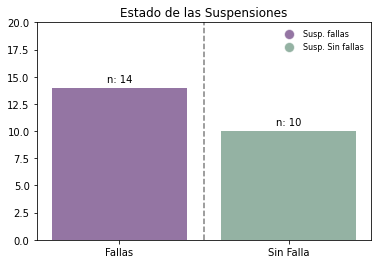

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Datos
names = ["Fallas", "Sin Falla"]
averages = [14, 10]
colors = [(0.3, 0.1, 0.4, 0.6), (0.3, 0.5, 0.4, 0.6)]

# Crear el gráfico de barras
fig, ax = plt.subplots()
bars = ax.bar(names, averages, color=colors)

# Añadir líneas de referencia
ax.axvline(x=0.5, color="grey", linestyle="--")

# Añadir texto sobre las barras
for bar, avg in zip(bars, averages):
    ax.text(bar.get_x() + bar.get_width()/2, avg + 0.5, f"n: {avg}", ha='center', fontsize=10)

# Añadir título
ax.set_title("Estado de las Suspensiones")

# Añadir leyenda
legend_labels = ["Susp. fallas", "Susp. Sin fallas"]
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markersize=10, markerfacecolor=c) for c in colors]
ax.legend(legend_patches, legend_labels, loc="upper right", fontsize=8, frameon=False)

# Mostrar el gráfico
plt.ylim(0, 20)
plt.show()

En el grafico anterior observamos la clasificacion del dataset.

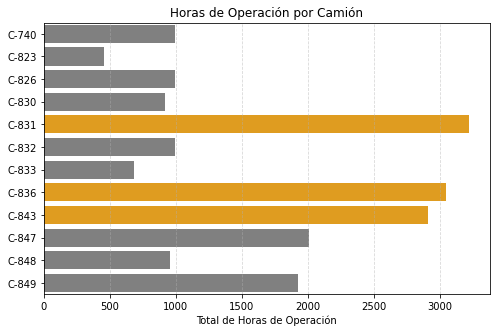

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar las horas por cada camión y ordenar de menor a mayor
data_summary = data.groupby("No_Equipo", as_index=False).agg(Total_Horas=("Horas", "sum"))
data_summary = data_summary.sort_values(by="Total_Horas")

# Cambiar "0220" por "C-"
data_summary["No_Equipo"] = data_summary["No_Equipo"].str.replace("^0220", "C-", regex=True)

# Ordenar alfabéticamente
data_summary = data_summary.sort_values(by="No_Equipo")

# Crear la columna de colores para resaltar los tres camiones con más horas
data_summary["highlight"] = np.where(data_summary["Total_Horas"].rank(method="min", ascending=False) <= 3, "orange", "grey")

# Asegurar que No_Equipo es de tipo string
data_summary["No_Equipo"] = data_summary["No_Equipo"].astype(str)

# Ordenar alfabéticamente por No_Equipo
data_summary = data_summary.sort_values(by="No_Equipo", ascending=True)

# Crear el gráfico
plt.figure(figsize=(8, 5))

sns.barplot(x="Total_Horas", y="No_Equipo", data=data_summary, palette=data_summary["highlight"].tolist())

# Ajustar título y etiquetas
plt.xlabel("Total de Horas de Operación")
plt.ylabel("")
plt.title("Horas de Operación por Camión")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

 En este grafico de barras, observamos el tiempo en operacion de cada camion, lo que nos das una idea del tiempo de operacion antes de falla de cada suspension.

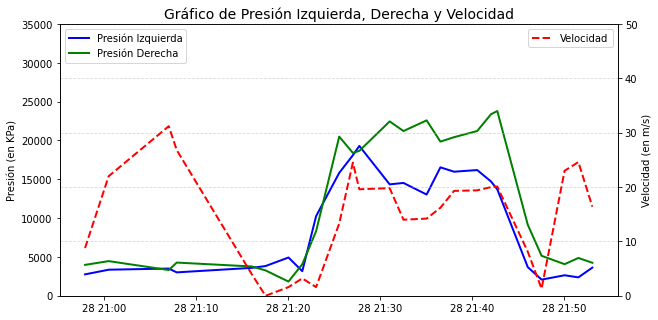

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar el camión específico
camion740 = dfcamiones[dfcamiones["EquipmentName"] == "022-740"].copy()

# Seleccionar solo los primeros 25 registros
subset_data = camion740.iloc[:25]

# Crear el gráfico
fig, ax1 = plt.subplots(figsize=(10, 5))

# Graficar la presión izquierda y derecha en el eje Y principal
ax1.plot(subset_data["AdjustedReadTime"], subset_data["StrutPressLeftRear"], 
         label="Presión Izquierda", color="blue", linewidth=2)
ax1.plot(subset_data["AdjustedReadTime"], subset_data["StrutPressureRightRear"],  
         label="Presión Derecha", color="green", linewidth=2)

# Configurar eje Y principal
ax1.set_ylabel("Presión (en KPa)")
ax1.set_ylim(0, 35000)
ax1.legend(loc="upper left")

# Crear segundo eje Y para la velocidad
ax2 = ax1.twinx()
ax2.plot(subset_data["AdjustedReadTime"], subset_data["Road Ground"],  
         label="Velocidad", color="red", linewidth=2, linestyle="dashed")

# Configurar eje Y secundario
ax2.set_ylabel("Velocidad (en m/s)")
ax2.set_ylim(0, 50)
ax2.legend(loc="upper right")

# Ajustar título y etiquetas
plt.title("Gráfico de Presión Izquierda, Derecha y Velocidad", fontsize=14)
plt.xlabel("Tiempo")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

# Mostrar el gráfico
plt.show()

Podemos ver el comportamiento de la presion de las suspensiones y la velocidad durante un ciclo de carga

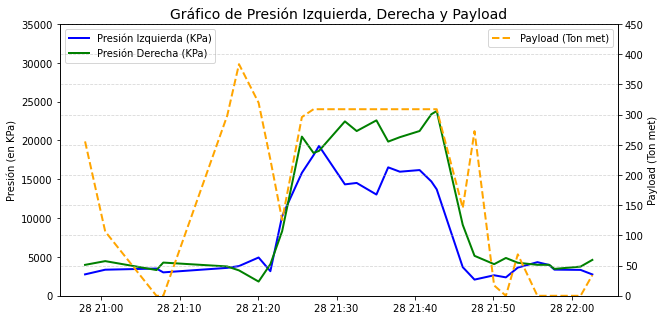

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar el camión específico
camion740 = dfcamiones[dfcamiones["EquipmentName"] == "022-740"].copy()

# Seleccionar los primeros 30 registros
subset_data = camion740.iloc[:30]

# Crear el gráfico
fig, ax1 = plt.subplots(figsize=(10, 5))

# Graficar las presiones en el eje Y principal
ax1.plot(subset_data["AdjustedReadTime"], subset_data["StrutPressLeftRear"], 
         label="Presión Izquierda (KPa)", color="blue", linewidth=2)
ax1.plot(subset_data["AdjustedReadTime"], subset_data["StrutPressureRightRear"],  
         label="Presión Derecha (KPa)", color="green", linewidth=2)

# Configurar eje Y principal (Presión)
ax1.set_ylabel("Presión (en KPa)")
ax1.set_ylim(0, 35000)
ax1.legend(loc="upper left")

# Crear segundo eje Y para el Payload
ax2 = ax1.twinx()
ax2.plot(subset_data["AdjustedReadTime"], subset_data["PayLoad"],  
         label="Payload (Ton met)", color="orange", linewidth=2, linestyle="dashed")

# Configurar eje Y secundario (Payload)
ax2.set_ylabel("Payload (Ton met)")
ax2.set_ylim(0, 450)
ax2.legend(loc="upper right")

# Ajustar título y etiquetas
plt.title("Gráfico de Presión Izquierda, Derecha y Payload", fontsize=14)
plt.xlabel("Tiempo")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

# Mostrar el gráfico
plt.show()

Observamos el comportamiento de la carga de esteril (Payload) durante el ciclo de operacion del camion. 

### Etapa de transporte